# ポートフォリオゲーム ボラティリティ分析

**yfinance**（Yahoo Finance）で指定30銘柄の株価・ボラティリティ・相関を分析。

```bash
pip install yfinance pandas numpy matplotlib seaborn jupyter
```
東証銘柄は **コード + `.T`** で取得（例: 任天堂 → `7974.T`）。

## 1. セットアップ

In [17]:
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# matplotlibで日本語表示
plt.rcParams['font.family'] = ['Hiragino Sans', 'Yu Gothic', 'Meiryo', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
print('ready')

ready


## 2. 指定30銘柄を読み込み

In [11]:
stocks = pd.read_csv(ROOT / 'data' / 'stocks.csv')
stocks['ticker'] = stocks['code'].astype(str).str.zfill(4) + '.T'  # 東証 = .T
print(f'{len(stocks)} 銘柄ロード')
stocks.head()

30 銘柄ロード


,code,name,sector,sub_sector,market_cap_oku_jpy,ticker
0,7974,任天堂,エンタメ,ゲーム,8949.7,7974.T
1,9602,東宝,エンタメ,コンテンツ,1222.5,9602.T
2,9766,コナミ,エンタメ,ゲーム,2562.0,9766.T
3,9684,スクウェア・エニックス・ホールディングス,エンタメ,ゲーム,886.0,9684.T
4,4816,東映アニメーション,エンタメ,コンテンツ,534.3,4816.T


## 3. 日次株価データ取得（過去1年）

In [12]:
tickers = stocks['ticker'].tolist()
to_date = datetime.today()
from_date = to_date - timedelta(days=365)
print(f'期間: {from_date.date()} 〜 {to_date.date()}')

raw = yf.download(
    tickers,
    start=from_date.strftime('%Y-%m-%d'),
    end=to_date.strftime('%Y-%m-%d'),
    auto_adjust=True,   # 分割・配当調整済み価格
    progress=False,
    group_by='ticker',
)

# ティッカー → 社名へリネーム
ticker_to_name = dict(zip(stocks['ticker'], stocks['name']))
close = pd.concat({ticker_to_name[t]: raw[t]['Close'] for t in tickers if t in raw.columns.get_level_values(0)}, axis=1)
close = close.dropna(how='all').sort_index()
print(f'価格パネル shape={close.shape}')
close.tail()

期間: 2025-05-19 〜 2026-05-19
価格パネル shape=(243, 30)


,任天堂,東宝,コナミ,スクウェア・エニックス・ホールディングス,東映アニメーション,ソニーグループ,東映,カプコン,ANYCOLOR,松竹,...,ニトリ,ZOZO,パン・パシフィック・インターナショナルホールディングス,ファーストリテイリング,サイゼリヤ,セブン＆アイ・ホールディングス,ワークマン,日本マクドナルドホールディングス,イオン,くら寿司
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-12,7179.0,1357.5,20275.0,2483.0,2821.0,3484.0,5910.0,3431.0,2751.0,10200.0,...,2336.0,1001.0,893.799988,72220.0,5040.0,1879.0,7120.0,7690.0,1500.0,1536.0
2026-05-13,7141.0,1364.5,20160.0,2533.5,2820.0,3660.0,5960.0,3296.0,2818.0,10220.0,...,2303.0,1018.0,883.599976,72500.0,5100.0,1873.5,7040.0,8590.0,1522.5,1552.0
2026-05-14,6864.0,1301.0,19540.0,2476.0,2600.0,3444.0,5890.0,3049.0,2765.0,10200.0,...,2265.0,1025.0,858.000000,71330.0,5160.0,1850.5,7250.0,8330.0,1477.0,1540.0
2026-05-15,7151.0,1317.0,19650.0,2654.0,2758.0,3576.0,5970.0,3065.0,2743.0,10510.0,...,2415.0,1044.0,871.299988,71630.0,5130.0,1862.5,7160.0,8130.0,1497.5,1565.0
2026-05-18,7182.0,1289.5,18735.0,2662.5,2600.0,3596.0,5860.0,3042.0,2766.0,10420.0,...,2426.5,1026.5,871.299988,70190.0,5100.0,1878.5,7170.0,7800.0,1421.0,1610.0


## 4. 日次リターン

In [13]:
returns = close.pct_change().dropna(how='all')
print(f'リターン shape={returns.shape}')
returns.tail()

リターン shape=(242, 30)


,任天堂,東宝,コナミ,スクウェア・エニックス・ホールディングス,東映アニメーション,ソニーグループ,東映,カプコン,ANYCOLOR,松竹,...,ニトリ,ZOZO,パン・パシフィック・インターナショナルホールディングス,ファーストリテイリング,サイゼリヤ,セブン＆アイ・ホールディングス,ワークマン,日本マクドナルドホールディングス,イオン,くら寿司
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-12,0.022650,-0.037916,-0.038644,0.000403,0.049479,0.033215,0.000000,-0.019994,-0.005063,-0.019231,...,-0.011008,-0.012333,-0.014879,-0.037708,-0.025145,-0.011573,-0.082474,-0.006460,-0.020888,-0.026616
2026-05-13,-0.005293,0.005157,-0.005672,0.020338,-0.000354,0.050517,0.008460,-0.039347,0.024355,0.001961,...,-0.014127,0.016983,-0.011412,0.003877,0.011905,-0.002927,-0.011236,0.117035,0.015000,0.010417
2026-05-14,-0.038790,-0.046537,-0.030754,-0.022696,-0.078014,-0.059016,-0.011745,-0.074939,-0.018808,-0.001957,...,-0.016500,0.006876,-0.028972,-0.016138,0.011765,-0.012276,0.029830,-0.030268,-0.029885,-0.007732
2026-05-15,0.041812,0.012298,0.005629,0.071890,0.060769,0.038328,0.013582,0.005248,-0.007957,0.030392,...,0.066225,0.018537,0.015501,0.004206,-0.005814,0.006485,-0.012414,-0.024010,0.013879,0.016234
2026-05-18,0.004335,-0.020881,-0.046565,0.003203,-0.057288,0.005593,-0.018425,-0.007504,0.008385,-0.008563,...,0.004762,-0.016762,0.000000,-0.020103,-0.005848,0.008591,0.001397,-0.040590,-0.051085,0.028754


## 5. 年率ボラティリティ / 年率リターン / シャープ
$\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$

In [14]:
TRADING_DAYS = 252
annual_vol = returns.std() * np.sqrt(TRADING_DAYS)
annual_ret = returns.mean() * TRADING_DAYS
sharpe = annual_ret / annual_vol  # 無リスク金利 0% 想定

name_to_sector = dict(zip(stocks['name'], stocks['sector']))
summary = pd.DataFrame({
    'sector': annual_vol.index.map(name_to_sector),
    'annual_return': annual_ret,
    'annual_volatility': annual_vol,
    'sharpe': sharpe,
}).sort_values('annual_volatility', ascending=False)
summary.style.format({'annual_return': '{:.2%}', 'annual_volatility': '{:.2%}', 'sharpe': '{:.2f}'})

,sector,annual_return,annual_volatility,sharpe
ANYCOLOR,エンタメ,-16.89%,52.73%,-0.32
コナミ,エンタメ,5.18%,40.26%,0.13
カプコン,エンタメ,-23.65%,39.05%,-0.61
イオン,小売,6.09%,37.94%,0.16
任天堂,エンタメ,-40.74%,37.34%,-1.09
サイゼリヤ,小売,9.78%,36.19%,0.27
ワークマン,小売,44.53%,36.08%,1.23
東映アニメーション,エンタメ,-19.35%,34.75%,-0.56
ニトリ,小売,-17.30%,34.55%,-0.50
ソニーグループ,エンタメ,6.20%,34.53%,0.18


## 6. 可視化

findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found

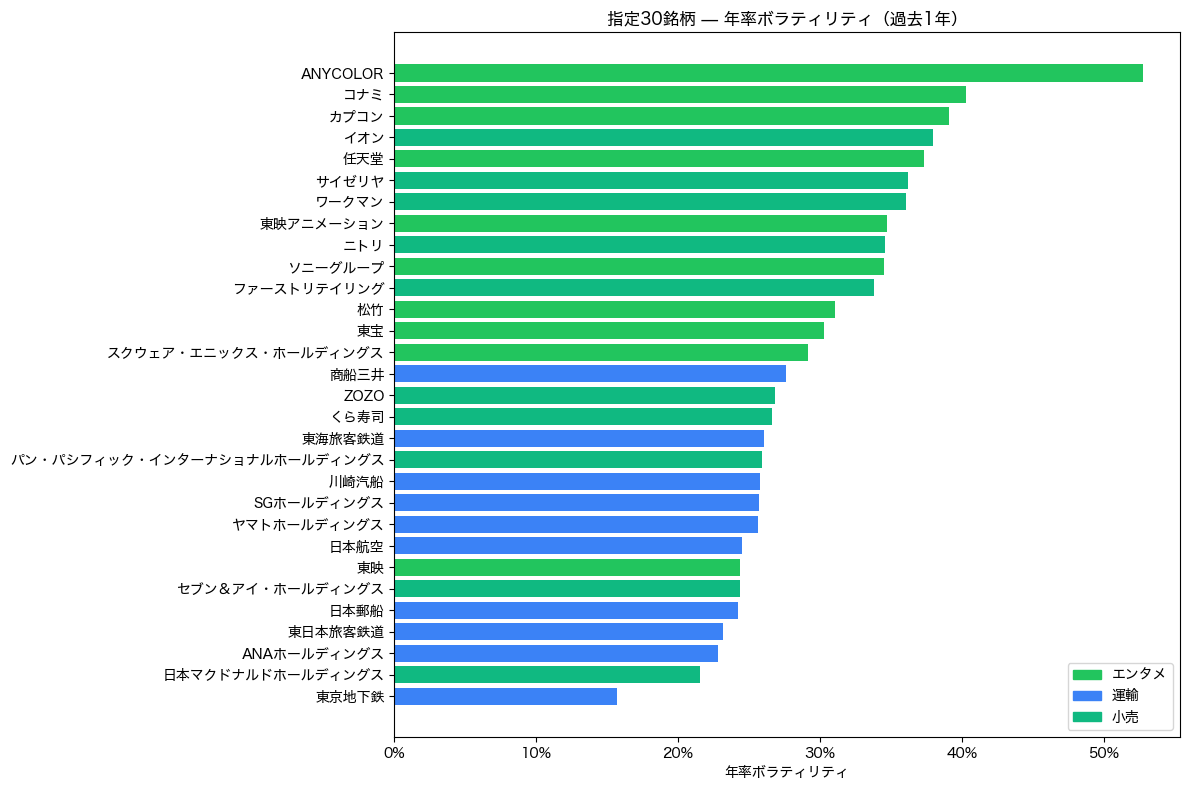

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))
colors = {'エンタメ': '#22c55e', '運輸': '#3b82f6', '小売': '#10b981'}
ordered = summary.sort_values('annual_volatility')
ax.barh(ordered.index, ordered['annual_volatility'], color=[colors[s] for s in ordered['sector']])
ax.set_xlabel('年率ボラティリティ')
ax.set_title('指定30銘柄 — 年率ボラティリティ（過去1年）')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=s) for s, c in colors.items()])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found

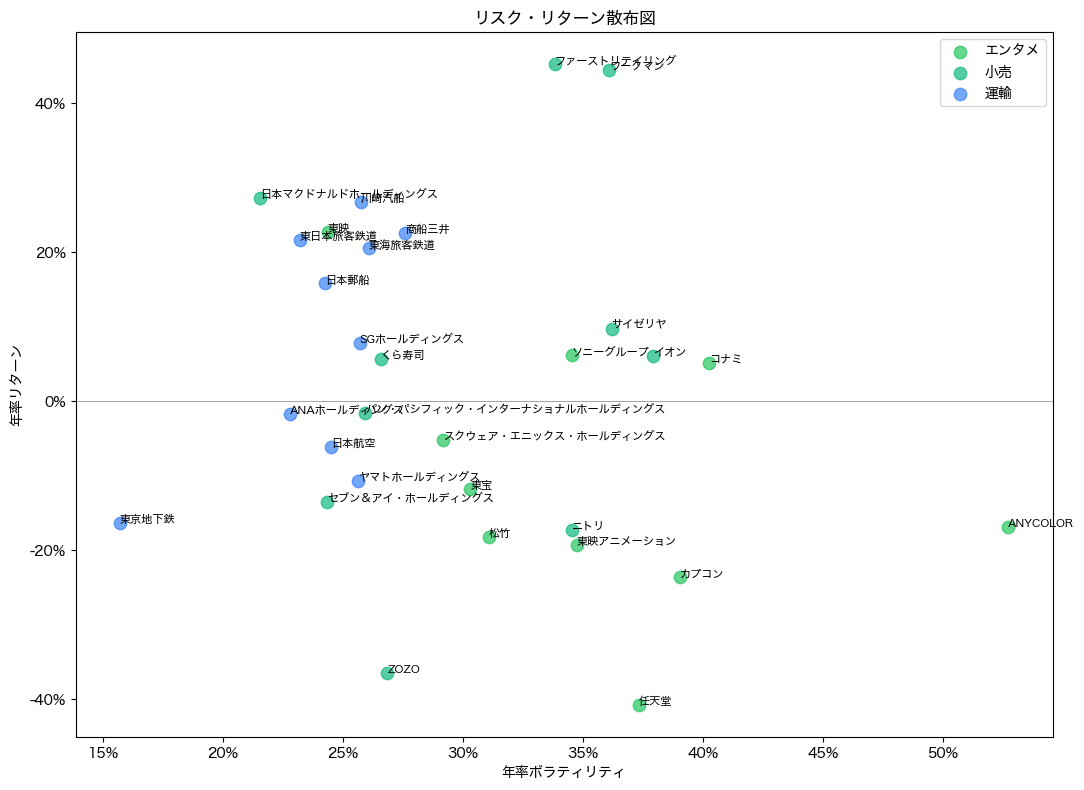

In [20]:
fig, ax = plt.subplots(figsize=(11, 8))
for sector, group in summary.groupby('sector'):
    ax.scatter(group['annual_volatility'], group['annual_return'], label=sector, s=80, alpha=0.7, color=colors[sector])
    for name, row in group.iterrows():
        ax.annotate(name, (row['annual_volatility'], row['annual_return']), fontsize=8)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('年率ボラティリティ')
ax.set_ylabel('年率リターン')
ax.set_title('リスク・リターン散布図')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()

findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found

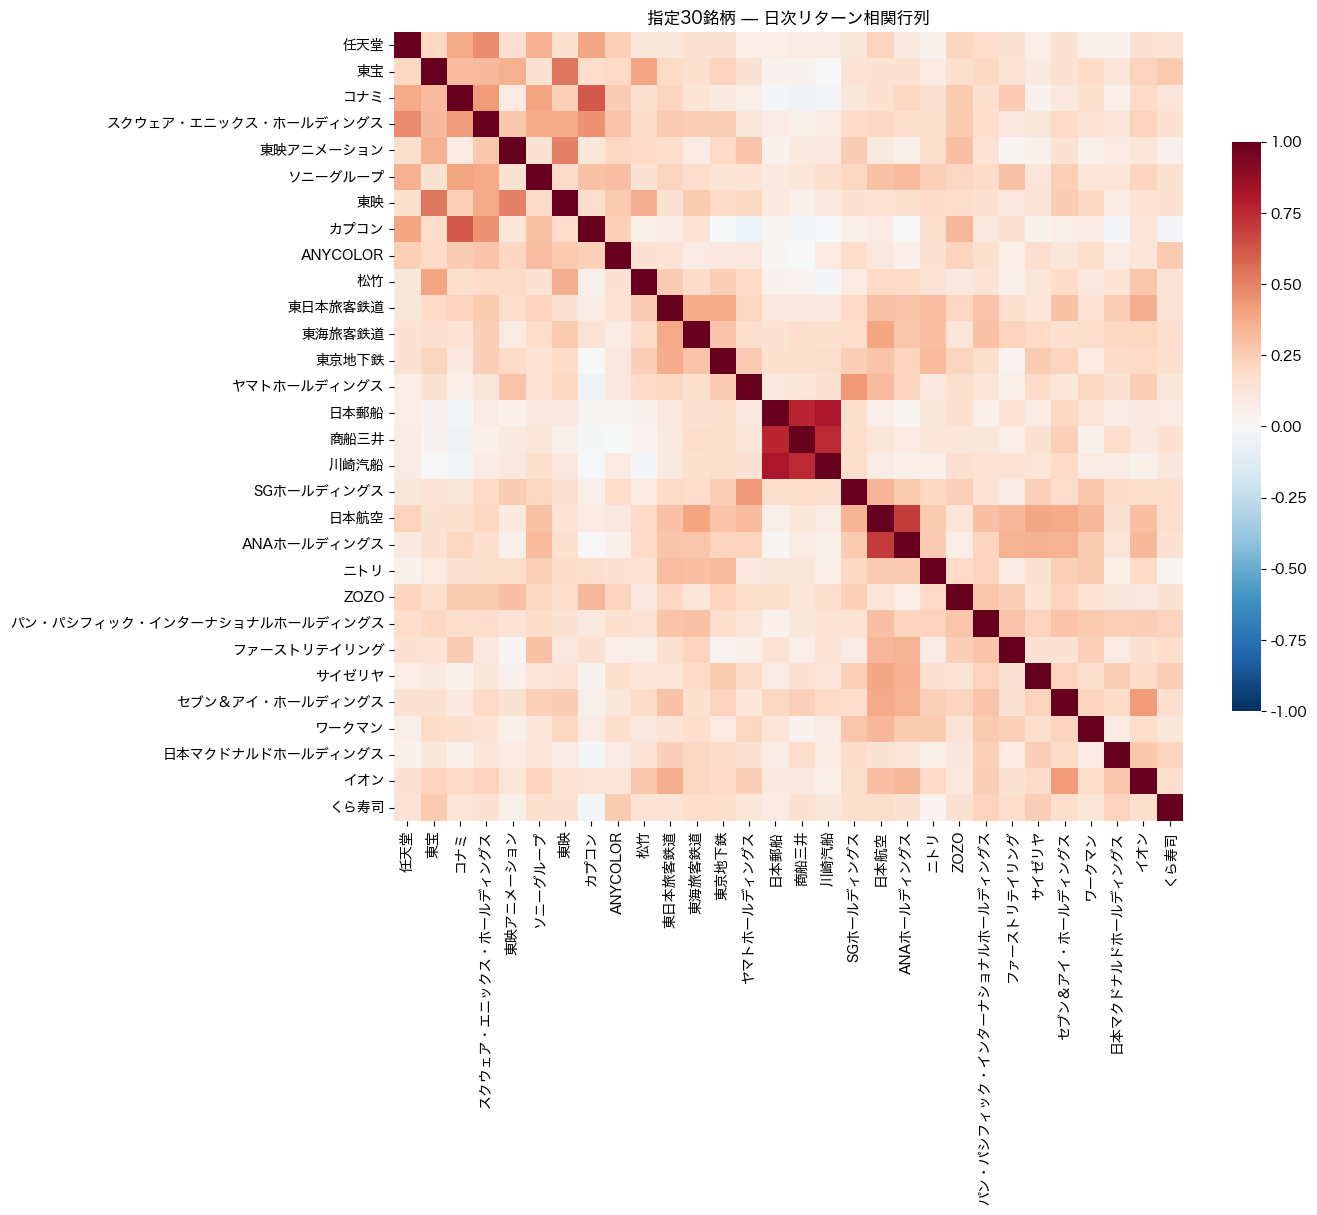

In [8]:
corr = returns.corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, annot=False, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('指定30銘柄 — 日次リターン相関行列')
plt.tight_layout()
plt.show()

## 7. ローリング・ボラ（20日 ≒ 1ヶ月）

findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Yu Gothic' not found

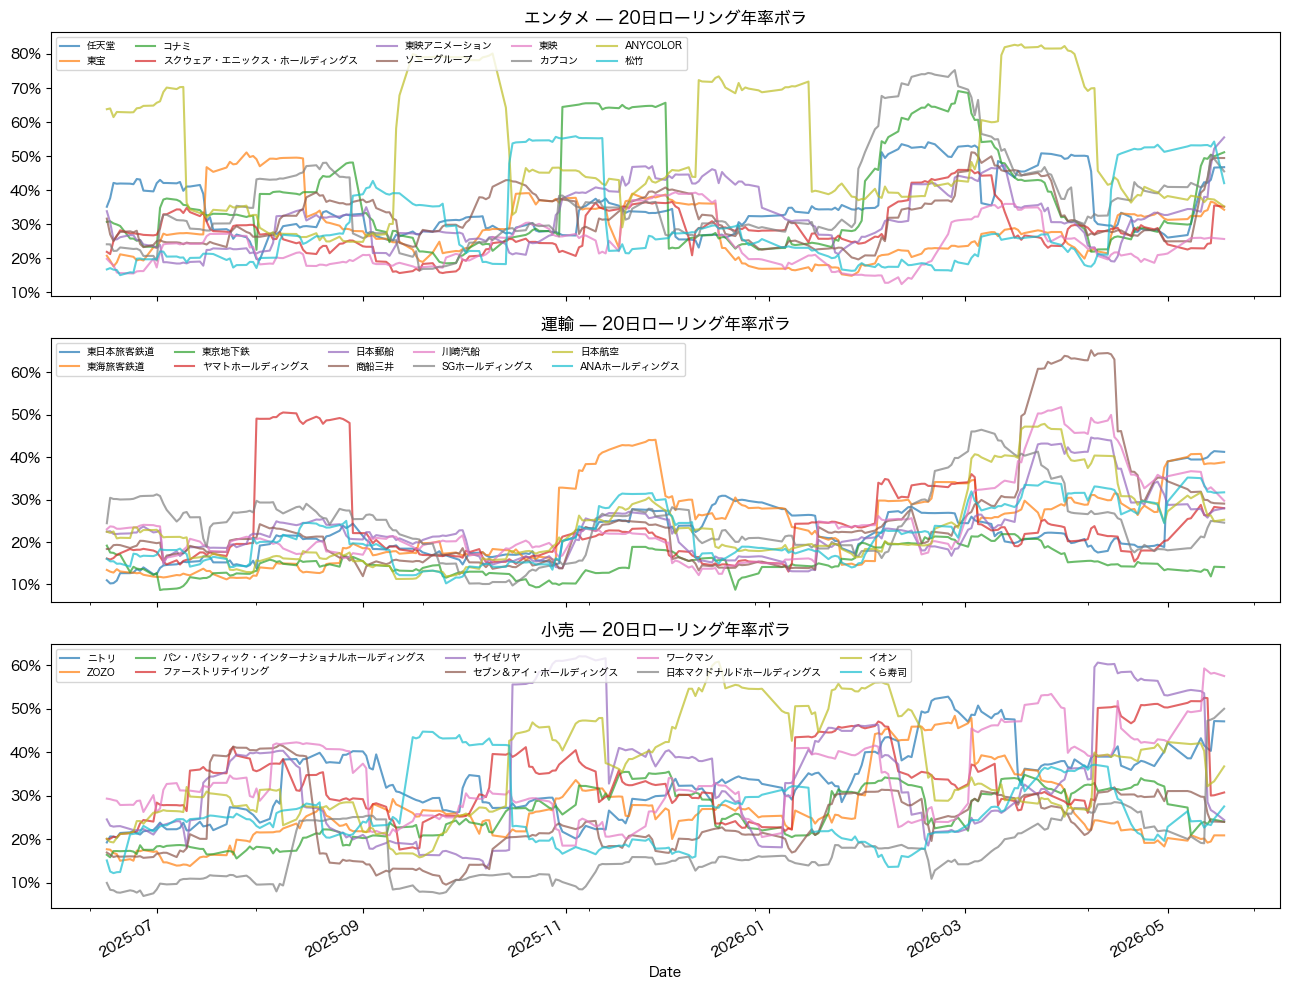

In [9]:
WINDOW = 20
rolling_vol = returns.rolling(WINDOW).std() * np.sqrt(TRADING_DAYS)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, sector in zip(axes, ['エンタメ', '運輸', '小売']):
    cols = [n for n in rolling_vol.columns if name_to_sector.get(n) == sector]
    rolling_vol[cols].plot(ax=ax, legend=False, alpha=0.7)
    ax.set_title(f'{sector} — 20日ローリング年率ボラ')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend(fontsize=7, ncol=5, loc='upper left')
plt.tight_layout()
plt.show()

## 8. データ書き出し（任意）

In [ ]:
OUT = ROOT / 'analysis' / 'output'
OUT.mkdir(exist_ok=True)
summary.to_csv(OUT / 'summary_metrics.csv')
close.to_csv(OUT / 'close_prices.csv')
returns.to_csv(OUT / 'daily_returns.csv')
print('saved to', OUT)